# QS World Ranking — SVM Classification

**Goal.** Classify each institution directly into a performance tier — **Low**, **Medium** or **High** — using a Support Vector Machine **classifier** (`SVC`).

The target `score_category` is derived from `overall_score`, grouped into three tiers:

| Tier | Overall Score range |
|------|--------------------|
| Low | 11 – 18 |
| Medium | 19 – 28 |
| High | 29 – 100 |

**Method — SVM classification with hyperparameter tuning.** Unlike the regression notebook, the SVM predicts the tier label directly (no regression, no binning). `GridSearchCV` searches over the key SVM hyperparameters:

- **kernel** — `linear`, `rbf`, `poly`
- **C** — the penalty / regularisation strength (`0.1, 1, 10, 100`)
- **gamma** — the RBF/poly kernel coefficient (`scale, 0.01, 0.1, 1`)

**Two feature sets** are tuned and evaluated separately:

- **Without ranks** — the eight QS component *scores* plus institutional attributes.
- **With ranks** — the same, plus the eight QS component *rank* columns.

Each is tuned by 5-fold grid search on a training split, evaluated on a hold-out test set, and cross-validated (10-fold) for stability.

> Leakage note: `overall_score` defines the target and is never a feature. The overall QS `rank` / `rank_numeric` is a direct ordering of `overall_score`, so it too is excluded. Only the eight *component* rank columns are added in the "with ranks" set. Features are standardised, which SVMs require.

In [ ]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
import seaborn as sns

from sklearn.model_selection import (
    train_test_split, GridSearchCV, cross_val_score, StratifiedKFold,
)
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay,
)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 40)
RANDOM_STATE = 42

## 1. Load the cleaned data

In [ ]:
df = pd.read_excel("QS_world_ranking.xlsx", sheet_name="Cleaned_Data")

df = df.loc[:, ~df.columns.str.startswith("Unnamed")]
df.columns = df.columns.str.strip()

print("Shape:", df.shape)
df.head()

Shape: (7431, 29)


,year,institution,country,academic_reputation_rank,academic_reputation_score,citations_per_faculty_rank,citations_per_faculty_score,employer_reputation_rank,employer_reputation_score,employment_outcomes_rank,employment_outcomes_score,faculty_student_ratio_rank,faculty_student_ratio_score,international_faculty_ratio_rank,international_faculty_ratio_score,international_research_network_rank,international_research_network_score,international_students_ratio_rank,international_students_ratio_score,research,size,rank_numeric,size_ordinal,research_ordinal,Private,Public,score_category,overall_score,rank
0,2023,Massachusetts Institute of Technology (MIT),United States,5,100.0,5,100.0,4,100.0,3,100.0,14,100.0,54,100.0,58,96.1,109,90.0,VH,M,1.0,2,4,1,0,High,100.0,1
1,2023,University of Cambridge,United Kingdom,2,100.0,55,92.3,2,100.0,9,100.0,11,100.0,60,100.0,6,99.5,70,96.3,VH,L,2.0,3,4,0,1,High,98.8,2
2,2023,Stanford University,United States,4,100.0,9,99.9,5,100.0,2,100.0,6,100.0,74,99.8,55,96.3,235,60.3,VH,L,3.0,3,4,1,0,High,98.5,3
3,2023,University of Oxford,United Kingdom,3,100.0,64,90.0,3,100.0,7,100.0,8,100.0,101,98.8,3,99.9,54,98.4,VH,L,4.0,3,4,0,1,High,98.4,4
4,2023,Harvard University,United States,1,100.0,2,100.0,1,100.0,1,100.0,35,99.4,228,76.9,1,100.0,212,66.9,VH,L,5.0,3,4,1,0,High,97.6,5


## 2. Target variable — the three performance tiers

score_category
Low       2612
High      2466
Medium    2353
Name: count, dtype: int64


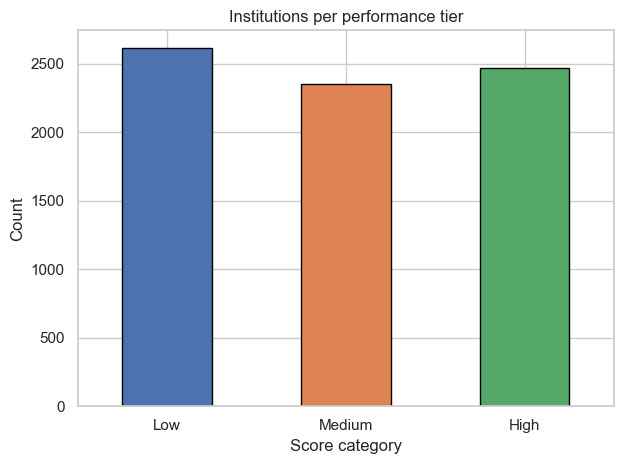

In [ ]:
print(df["score_category"].value_counts())

ax = df["score_category"].value_counts().reindex(["Low", "Medium", "High"]).plot(
    kind="bar", color=["#4C72B0", "#DD8452", "#55A868"], edgecolor="black"
)
ax.set_title("Institutions per performance tier")
ax.set_xlabel("Score category")
ax.set_ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
tier_ranges = (
    df.groupby("score_category")["overall_score"]
      .agg(["min", "max", "count"])
      .reindex(["Low", "Medium", "High"])
)
print(tier_ranges)

                      min         max  count
score_category                              
Low             11.418222   18.035674   2612
Medium          18.997531   28.300000   2353
High            28.329192  100.000000   2466


## 3. Clean the component rank columns

The eight `*_rank` columns are stored as text and contain banded values such as `501+`, `601+`. We strip the `+` and convert to a numeric rank so they can be used as features.

In [ ]:
rank_cols = [
    "academic_reputation_rank",
    "citations_per_faculty_rank",
    "employer_reputation_rank",
    "employment_outcomes_rank",
    "faculty_student_ratio_rank",
    "international_faculty_ratio_rank",
    "international_research_network_rank",
    "international_students_ratio_rank",
]

for c in rank_cols:
    df[c] = (
        df[c].astype(str)
             .str.replace("+", "", regex=False)
             .str.strip()
    )
    df[c] = pd.to_numeric(df[c], errors="coerce")

df[rank_cols] = df[rank_cols].fillna(df[rank_cols].max())
print(df[rank_cols].describe().T[["min", "max", "mean"]].round(1))

                                     min     max   mean
academic_reputation_rank             1.0   701.0  490.9
citations_per_faculty_rank           1.0   934.0  545.7
employer_reputation_rank             1.0   778.0  491.1
employment_outcomes_rank             1.0  1012.0  547.9
faculty_student_ratio_rank           1.0   801.0  547.7
international_faculty_ratio_rank     1.0  1198.0  546.4
international_research_network_rank  1.0  1239.0  546.4
international_students_ratio_rank    1.0  1148.0  545.4


## 4. Feature sets and the classification target

In [ ]:
score_features = [
    "academic_reputation_score",
    "citations_per_faculty_score",
    "employer_reputation_score",
    "employment_outcomes_score",
    "faculty_student_ratio_score",
    "international_faculty_ratio_score",
    "international_students_ratio_score",
    "international_research_network_score",
]
attribute_features = ["size_ordinal", "research_ordinal", "Private", "Public"]

feature_sets = {
    "Without ranks": score_features + attribute_features,
    "With ranks":    score_features + attribute_features + rank_cols,
}
for name, feats in feature_sets.items():
    print(f"{name:14s}: {len(feats)} features")

# Classification target (the tier label) — SVC predicts this directly
y = df["score_category"]
tier_order = ["Low", "Medium", "High"]

Without ranks : 12 features
With ranks    : 20 features


## 5. Hyperparameter tuning with GridSearchCV

For each feature set we split 75/25 (stratified), then run a 5-fold grid search over `kernel`, `C` and `gamma` on the training data. `gamma` only applies to the `rbf`/`poly` kernels, so the grid is split into two blocks to avoid redundant fits.

In [ ]:
param_grid = [
    {"svc__kernel": ["linear"],
     "svc__C": [0.1, 1, 10]},
    {"svc__kernel": ["rbf", "poly"],
     "svc__C": [0.1, 1, 10],
     "svc__gamma": ["scale", 0.01, 0.1, 1]},
]

searches = {}   # feature set -> fitted GridSearchCV
splits   = {}   # feature set -> (X_train, X_test, y_train, y_test)

for set_name, feats in feature_sets.items():
    X = df[feats]
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
    )
    pipe = make_pipeline(StandardScaler(), SVC())
    gs = GridSearchCV(pipe, param_grid, cv=5, scoring="accuracy", n_jobs=-1)
    gs.fit(X_tr, y_tr)
    searches[set_name] = gs
    splits[set_name] = (X_tr, X_te, y_tr, y_te)
    best = {k.replace("svc__", ""): v for k, v in gs.best_params_.items()}
    print(f"{set_name:14s} -> best {best} | best CV acc = {gs.best_score_:.4f}")

Without ranks  -> best {'C': 10, 'gamma': 0.01, 'kernel': 'rbf'} | best CV acc = 0.8663
With ranks     -> best {'C': 10, 'gamma': 0.01, 'kernel': 'rbf'} | best CV acc = 0.9261


## 6. Hold-out evaluation of the tuned models

In [ ]:
for set_name, gs in searches.items():
    X_tr, X_te, y_tr, y_te = splits[set_name]
    y_pred = gs.predict(X_te)
    print(f"===== {set_name} =====")
    print(f"Test accuracy: {accuracy_score(y_te, y_pred):.4f}\n")
    print(classification_report(y_te, y_pred, digits=3))
    print()

===== Without ranks =====
Test accuracy: 0.8794

              precision    recall  f1-score   support

        High      0.972     0.958     0.965       617
         Low      0.860     0.864     0.862       653
      Medium      0.806     0.815     0.810       588

    accuracy                          0.879      1858
   macro avg      0.879     0.879     0.879      1858
weighted avg      0.880     0.879     0.880      1858


===== With ranks =====
Test accuracy: 0.9370

              precision    recall  f1-score   support

        High      0.966     0.958     0.962       617
         Low      0.951     0.942     0.946       653
      Medium      0.893     0.910     0.901       588

    accuracy                          0.937      1858
   macro avg      0.936     0.937     0.936      1858
weighted avg      0.937     0.937     0.937      1858




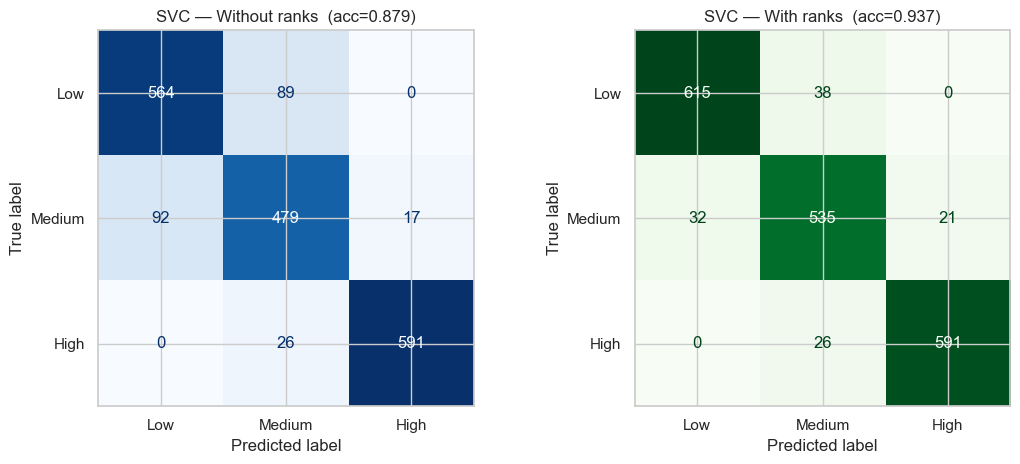

In [ ]:
# Confusion matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))
for ax, (set_name, gs), cmap in zip(axes, searches.items(), ["Blues", "Greens"]):
    X_tr, X_te, y_tr, y_te = splits[set_name]
    y_pred = gs.predict(X_te)
    cm = confusion_matrix(y_te, y_pred, labels=tier_order)
    ConfusionMatrixDisplay(cm, display_labels=tier_order).plot(
        cmap=cmap, ax=ax, colorbar=False, values_format="d")
    ax.set_title(f"SVC — {set_name}  (acc={accuracy_score(y_te, y_pred):.3f})")
plt.tight_layout()
plt.show()

## 7. Visualising the grid search (RBF kernel)

Heatmaps of mean cross-validated accuracy over the `C` × `gamma` grid for the RBF kernel — this shows how the tuning explored the hyperparameter space.

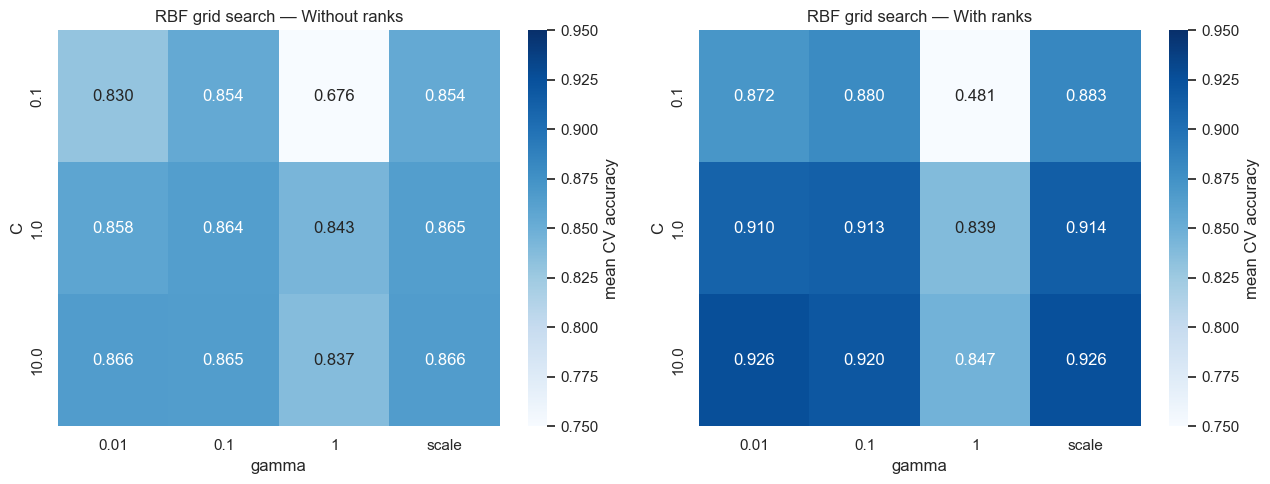

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (set_name, gs) in zip(axes, searches.items()):
    res = pd.DataFrame(gs.cv_results_)
    rbf = res[res["param_svc__kernel"] == "rbf"].copy()
    rbf["param_svc__gamma"] = rbf["param_svc__gamma"].astype(str)
    pivot = rbf.pivot_table(index="param_svc__C",
                            columns="param_svc__gamma",
                            values="mean_test_score")

    sns.heatmap(pivot, annot=True, fmt=".3f",
                cmap="Blues",
                vmin=0.75, vmax=0.95,
                ax=ax, cbar_kws={"label": "mean CV accuracy"})


    ax.set_title(f"RBF grid search — {set_name}")
    ax.set_xlabel("gamma")
    ax.set_ylabel("C")
plt.tight_layout()
plt.show()

## 8. 10-fold cross-validation of the tuned models

Using the best hyperparameters found for each feature set, we run 10-fold stratified cross-validation on the full dataset and compare the fold-by-fold accuracy.

In [ ]:
cv_scores = {}
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)
for set_name, feats in feature_sets.items():
    X = df[feats]
    cv_scores[set_name] = cross_val_score(
        searches[set_name].best_estimator_, X, y, cv=skf,
        scoring="accuracy", n_jobs=-1,
    )
    arr = cv_scores[set_name]
    print(f"{set_name:14s}: mean={arr.mean():.4f}  std={arr.std():.4f}  "
          f"min={arr.min():.4f}  max={arr.max():.4f}")

Without ranks : mean=0.8723  std=0.0078  min=0.8614  max=0.8869
With ranks    : mean=0.9295  std=0.0085  min=0.9125  max=0.9435


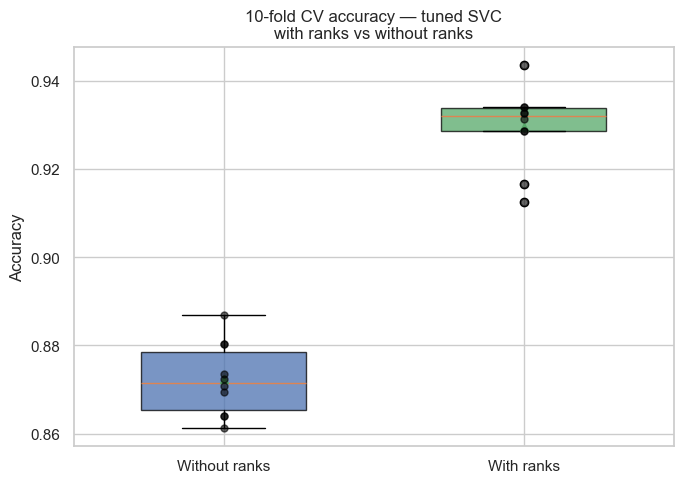

In [ ]:
# Boxplot of the 10-fold CV accuracies
colours = ["#4C72B0", "#55A868"]
fig, ax = plt.subplots(figsize=(7, 5))
data = [cv_scores["Without ranks"], cv_scores["With ranks"]]
bp = ax.boxplot(data, labels=["Without ranks", "With ranks"],
                patch_artist=True, widths=0.55, showmeans=True)
for patch, col in zip(bp["boxes"], colours):
    patch.set_facecolor(col)
    patch.set_alpha(0.75)
for i, d in enumerate(data, start=1):
    ax.scatter(np.full_like(d, i, dtype=float), d, color="black", alpha=0.6, zorder=3, s=25)
ax.set_title("10-fold CV accuracy — tuned SVC\nwith ranks vs without ranks")
ax.set_ylabel("Accuracy")
plt.tight_layout()
plt.show()

## 9. Comparison — with ranks vs without ranks

               Best CV (grid search)  Test accuracy  10-fold CV mean
Feature set                                                         
Without ranks                 0.8663         0.8794           0.8723
With ranks                    0.9261         0.9370           0.9295


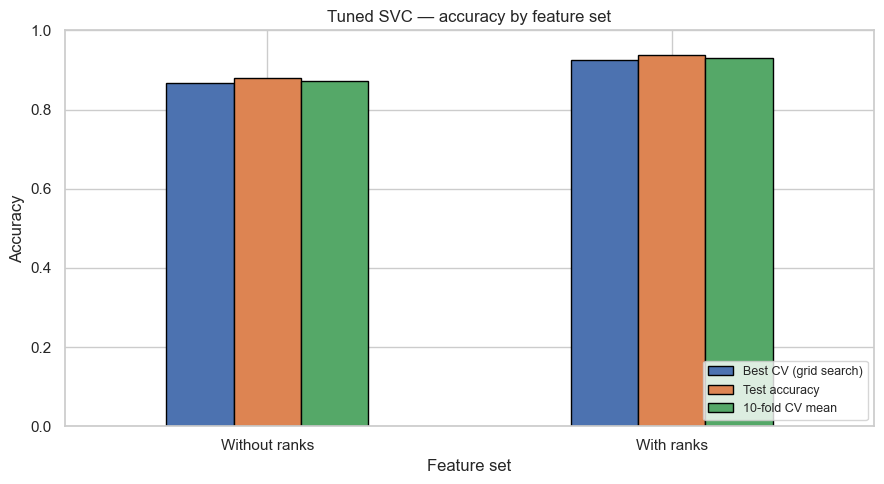

In [ ]:
summary = pd.DataFrame({
    "Feature set": ["Without ranks", "With ranks"],
    "Best CV (grid search)": [searches["Without ranks"].best_score_,
                              searches["With ranks"].best_score_],
    "Test accuracy": [
        accuracy_score(splits["Without ranks"][3],
                       searches["Without ranks"].predict(splits["Without ranks"][1])),
        accuracy_score(splits["With ranks"][3],
                       searches["With ranks"].predict(splits["With ranks"][1])),
    ],
    "10-fold CV mean": [cv_scores["Without ranks"].mean(),
                        cv_scores["With ranks"].mean()],
}).set_index("Feature set")
print(summary.round(4))

ax = summary.plot(kind="bar", figsize=(9, 5),
                  color=["#4C72B0", "#DD8452", "#55A868"], edgecolor="black")
ax.set_title("Tuned SVC — accuracy by feature set")
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1)
plt.xticks(rotation=0)
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()

## 09. Visualising the SVM decision boundary

The classifier works in many dimensions, so we cannot draw its full boundary. For intuition we fit an RBF SVC on the two most predictive score features and shade the tier it assigns to each region, with the data points overlaid.

Decision boundary on top-2 predictors: academic_reputation_score  &  employer_reputation_score


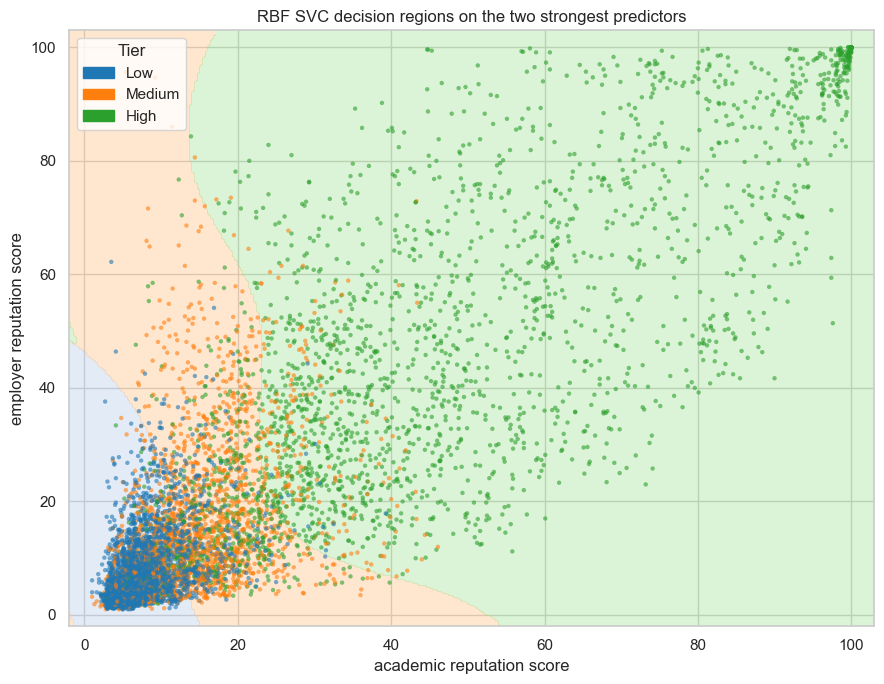

In [ ]:
corrs = df[score_features].corrwith(df["overall_score"]).abs().sort_values(ascending=False)
f1, f2 = corrs.index[0], corrs.index[1]
print(f"Decision boundary on top-2 predictors: {f1}  &  {f2}")

X2 = df[[f1, f2]].values
clf2 = make_pipeline(StandardScaler(), SVC(kernel="rbf", C=10, gamma="scale"))
clf2.fit(X2, y)

# Mesh over the two feature ranges
pad1 = 0.03 * (X2[:, 0].max() - X2[:, 0].min())
pad2 = 0.03 * (X2[:, 1].max() - X2[:, 1].min())
g1 = np.linspace(X2[:, 0].min() - pad1, X2[:, 0].max() + pad1, 300)
g2 = np.linspace(X2[:, 1].min() - pad2, X2[:, 1].max() + pad2, 300)
G1, G2 = np.meshgrid(g1, g2)
grid = np.column_stack([G1.ravel(), G2.ravel()])

# Predict tier for each grid point and map to an integer code for shading
Z = pd.Categorical(clf2.predict(grid), categories=tier_order).codes.reshape(G1.shape)
y_code = pd.Categorical(y, categories=tier_order).codes

region_cmap = ListedColormap(["#AEC7E8", "#FFBB78", "#98DF8A"])
point_cmap  = ListedColormap(["#1F77B4", "#FF7F0E", "#2CA02C"])

fig, ax = plt.subplots(figsize=(9, 7))
ax.contourf(G1, G2, Z, alpha=0.35, cmap=region_cmap, levels=[-0.5, 0.5, 1.5, 2.5])
sc = ax.scatter(X2[:, 0], X2[:, 1], c=y_code, cmap=point_cmap, s=10, alpha=0.6,
                edgecolor="none")
ax.set_xlabel(f1.replace("_", " "))
ax.set_ylabel(f2.replace("_", " "))
ax.set_title("RBF SVC decision regions on the two strongest predictors")
handles = [mpatches.Patch(color=point_cmap(i), label=t) for i, t in enumerate(tier_order)]
ax.legend(handles=handles, title="Tier", loc="upper left")
plt.tight_layout()
plt.show()

## 11. Summary

In [ ]:
best_overall = summary["10-fold CV mean"].idxmax()
print("Best hyperparameters found:\n")
for set_name, gs in searches.items():
    best = {k.replace("svc__", ""): v for k, v in gs.best_params_.items()}
    print(f"  {set_name:14s}: {best}")
print("\nAccuracy summary:\n")
print(summary.round(4))
print(f"\nBest feature set by 10-fold CV: {best_overall}")

Best hyperparameters found:

  Without ranks : {'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}
  With ranks    : {'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}

Accuracy summary:

               Best CV (grid search)  Test accuracy  10-fold CV mean
Feature set                                                         
Without ranks                 0.8663         0.8794           0.8723
With ranks                    0.9261         0.9370           0.9295

Best feature set by 10-fold CV: With ranks


### Findings

- **Method.** The SVM is used as a classifier (`SVC`) predicting the tier `score_category` directly — no regression, no binning.
- **Tuning.** `GridSearchCV` searched `kernel` × `C` × `gamma` by 5-fold cross-validation on the training split; the best configuration is reported per feature set and visualised in the RBF heatmaps.
- **With vs without ranks.** Adding the eight component rank columns raises accuracy and tightens the fold-to-fold spread (grouped bar and boxplot).
- **Kernel behaviour.** The RBF kernel typically wins here because it can bend the tier boundaries; the linear kernel is competitive since the underlying score is close to a linear combination of the pillars.
- Most residual errors sit between neighbouring tiers (Low↔Medium, Medium↔High), expected since the tiers are contiguous bands of one underlying score.